# Diabetes Dataset Exploration

Short exploratory notebook for the Phase 1 `sklearn` Diabetes dataset.
It reuses the project loader and preprocessing logic so the notebook stays aligned with the experiment code.

In [11]:
import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root containing 'src'.")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

In [12]:
import src.data.load_diabetes as load_diabetes_module
import src.data.preprocessing as preprocessing_module

load_diabetes_module = importlib.reload(load_diabetes_module)
preprocessing_module = importlib.reload(preprocessing_module)

load_diabetes_dataset = load_diabetes_module.load_diabetes_dataset
prepare_diabetes_tabular_data = preprocessing_module.prepare_diabetes_tabular_data

In [13]:
dataset = load_diabetes_dataset()
df = dataset.features.copy()
df["target"] = dataset.target

print(f"Dataset: {dataset.dataset_name}")
print(f"Rows: {df.shape[0]}")
print(f"Features: {dataset.features.shape[1]}")
df.head()

Dataset: diabetes
Rows: 442
Features: 10


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [14]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "mean": df.mean(numeric_only=True),
        "std": df.std(numeric_only=True),
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True),
    }
)
summary

,dtype,missing_values,mean,std,min,max
age,float64,0,-2.511817e-19,0.047619,-0.107226,0.110727
sex,float64,0,1.230790e-17,0.047619,-0.044642,0.050680
bmi,float64,0,-2.245564e-16,0.047619,-0.090275,0.170555
bp,float64,0,-4.797570e-17,0.047619,-0.112399,0.132044
s1,float64,0,-1.381499e-17,0.047619,-0.126781,0.153914
s2,float64,0,3.918434e-17,0.047619,-0.115613,0.198788
s3,float64,0,-5.777179e-18,0.047619,-0.102307,0.181179
s4,float64,0,-9.042540e-18,0.047619,-0.076395,0.185234
s5,float64,0,9.268604e-17,0.047619,-0.126097,0.133597
s6,float64,0,1.130318e-17,0.047619,-0.137767,0.135612


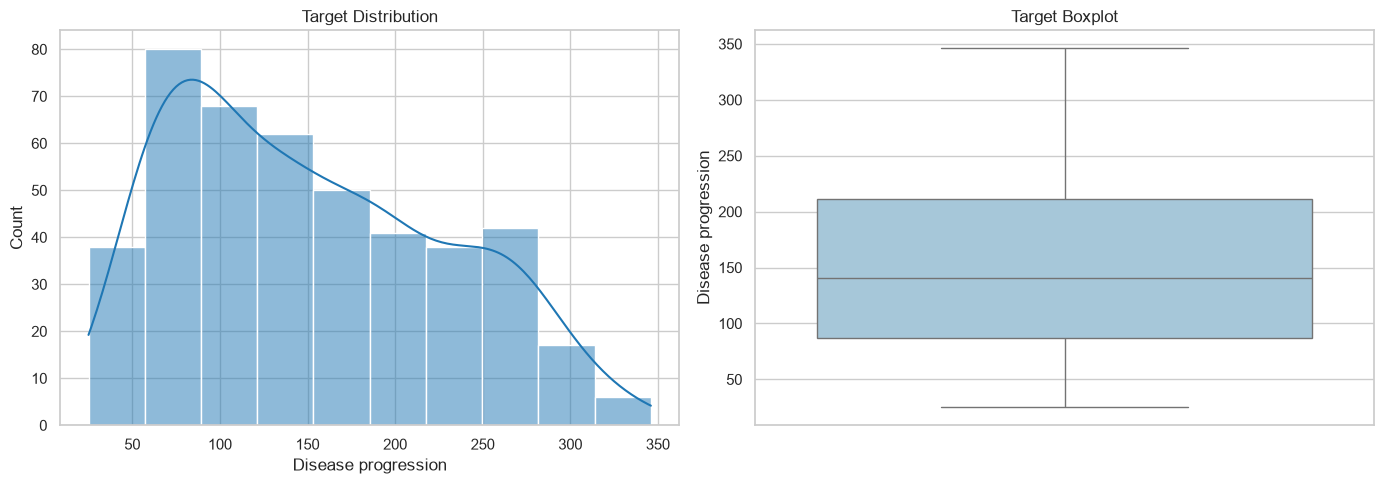

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["target"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Disease progression")

sns.boxplot(y=df["target"], ax=axes[1], color="#9ecae1")
axes[1].set_title("Target Boxplot")
axes[1].set_ylabel("Disease progression")

plt.tight_layout()

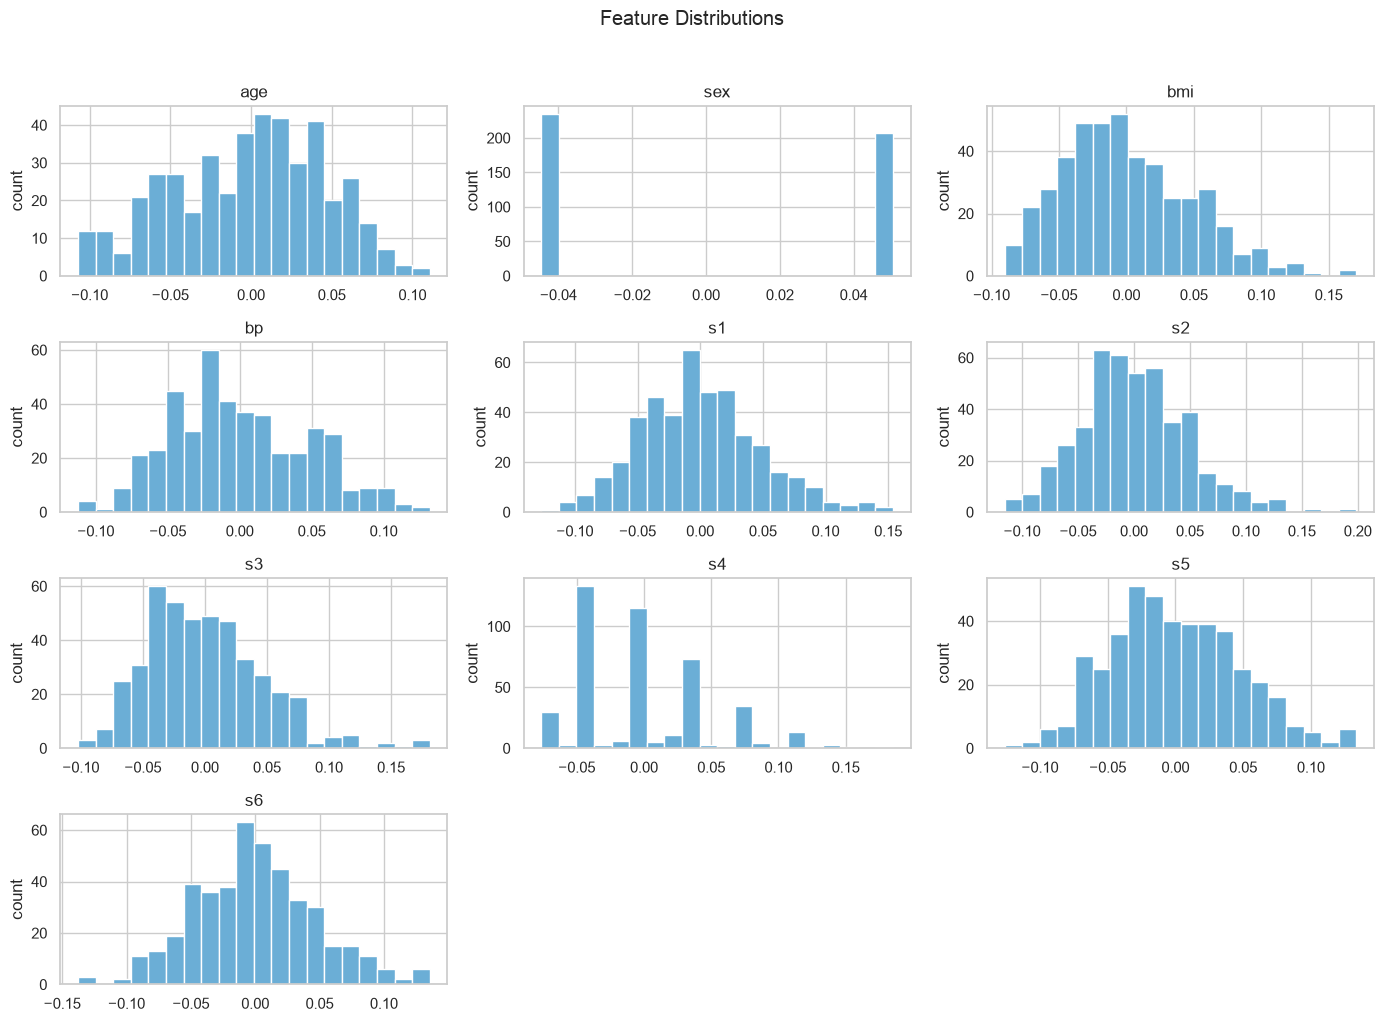

In [16]:
feature_axes = dataset.features.hist(figsize=(14, 10), bins=20, layout=(4, 3), color="#6baed6")
for ax in feature_axes.flatten():
    if ax is not None:
        ax.set_xlabel("")
        ax.set_ylabel("count")
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()

,corr_with_target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


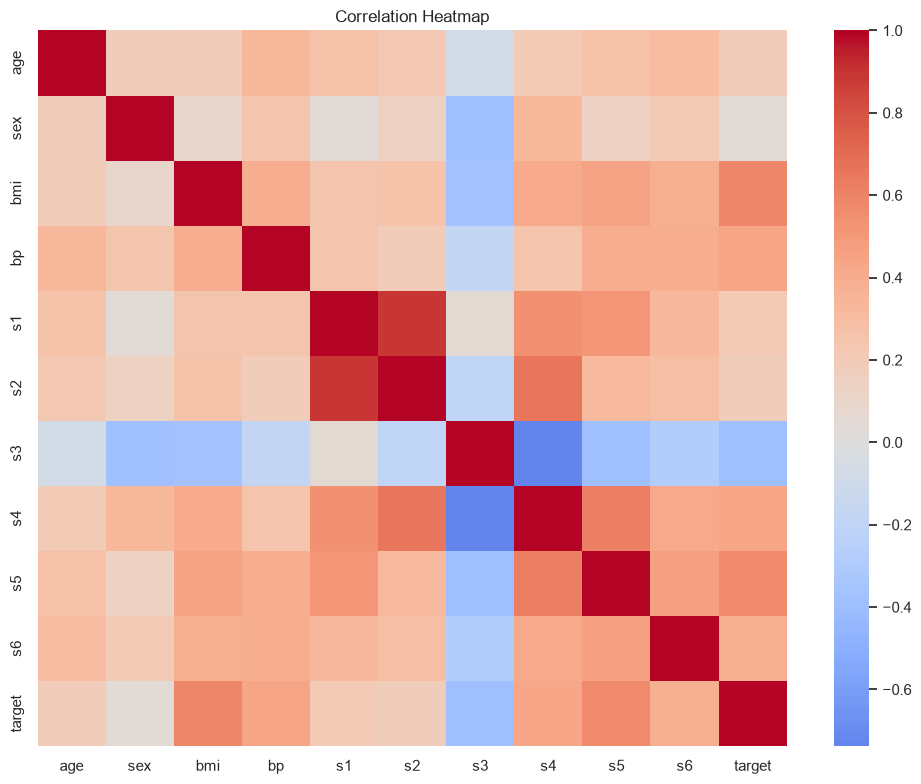

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()

corr["target"].sort_values(ascending=False).to_frame("corr_with_target")

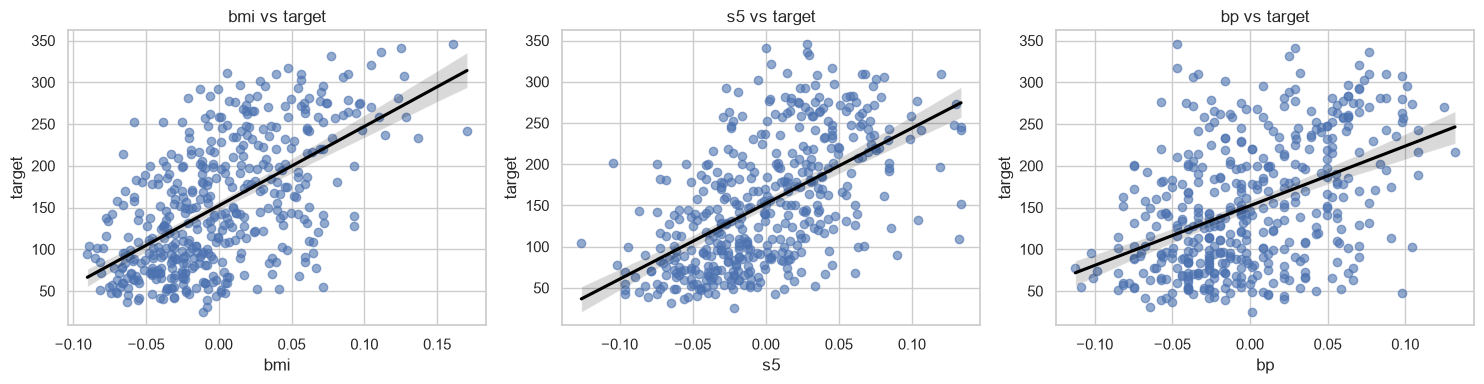

In [18]:
top_features = corr["target"].drop("target").abs().sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, len(top_features), figsize=(5 * len(top_features), 4))

if len(top_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, top_features):
    sns.regplot(data=df, x=feature, y="target", ax=ax, scatter_kws={"alpha": 0.6}, line_kws={"color": "black"})
    ax.set_title(f"{feature} vs target")

plt.tight_layout()

In [19]:
data_split = prepare_diabetes_tabular_data(dataset)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            len(data_split.train_indices),
            len(data_split.val_indices),
            len(data_split.test_indices),
        ],
        "target_mean": [
            data_split.y_train.mean(),
            data_split.y_val.mean(),
            data_split.y_test.mean(),
        ],
        "target_std": [
            data_split.y_train.std(),
            data_split.y_val.std(),
            data_split.y_test.std(),
        ],
    }
)
split_summary

,split,rows,target_mean,target_std
0,train,265,151.026415,77.330772
1,validation,88,145.056818,75.927052
2,test,89,162.426966,76.055995


In [20]:
scaled_train = pd.DataFrame(data_split.x_train_scaled, columns=data_split.feature_names)

pd.DataFrame(
    {
        "train_scaled_mean": scaled_train.mean(),
        "train_scaled_std": scaled_train.std(ddof=0),
    }
).head()

,train_scaled_mean,train_scaled_std
age,4.524683e-17,1.0
sex,-1.675808e-17,1.0
bmi,2.346132e-17,1.0
bp,-2.681293e-17,1.0
s1,-2.681293e-17,1.0


## Notes

- The Diabetes features are already normalized in the original `sklearn` dataset, but the project still applies train-only standardization for models that benefit from it.
- This notebook is intentionally lightweight and exploratory. Model training and metric reporting stay in `src/experiments/run_diabetes_experiment.py`.